# Figure 4 - Replication Deconvolution Results and Copy Correction


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src.replication_timing import ReplicationTiming

replication_timings = ReplicationTiming('output/draft3_run/')

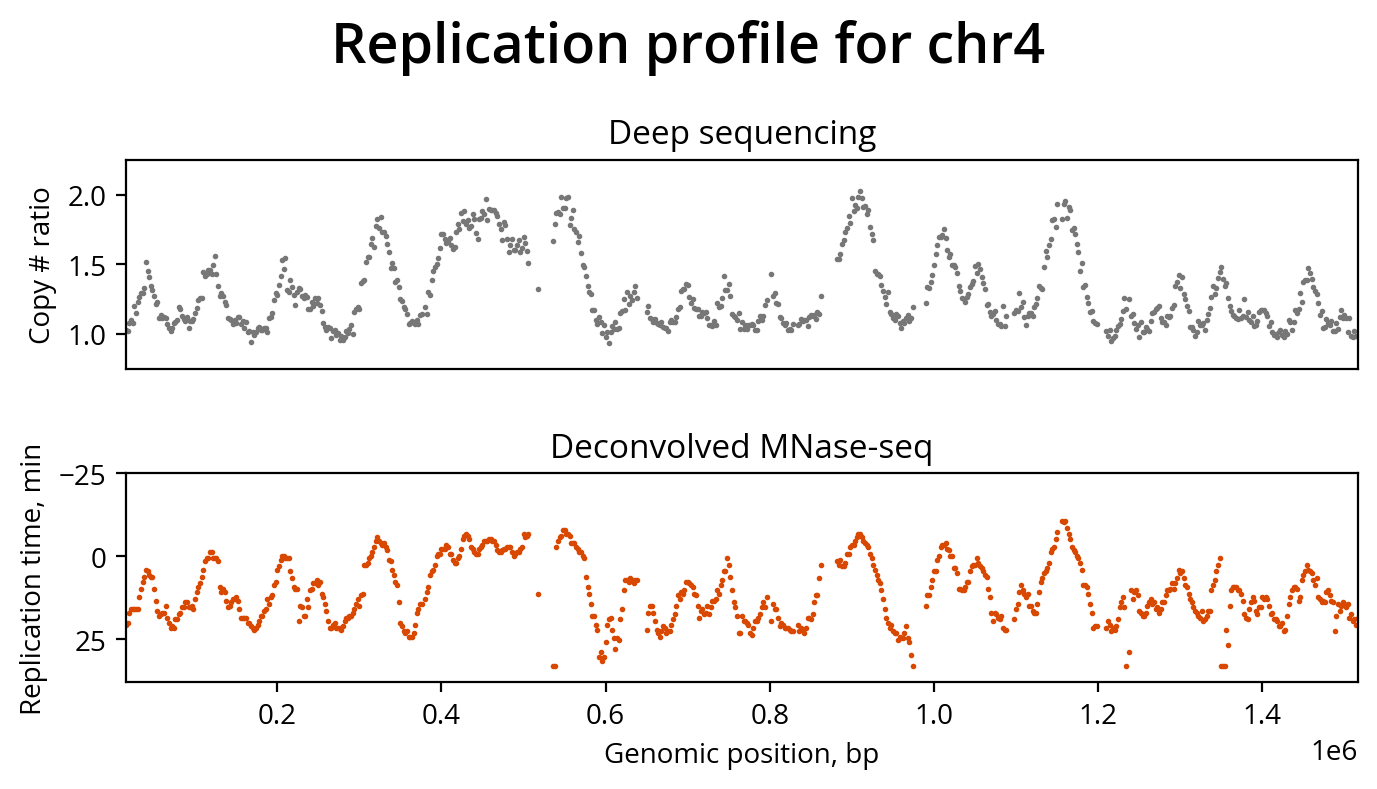

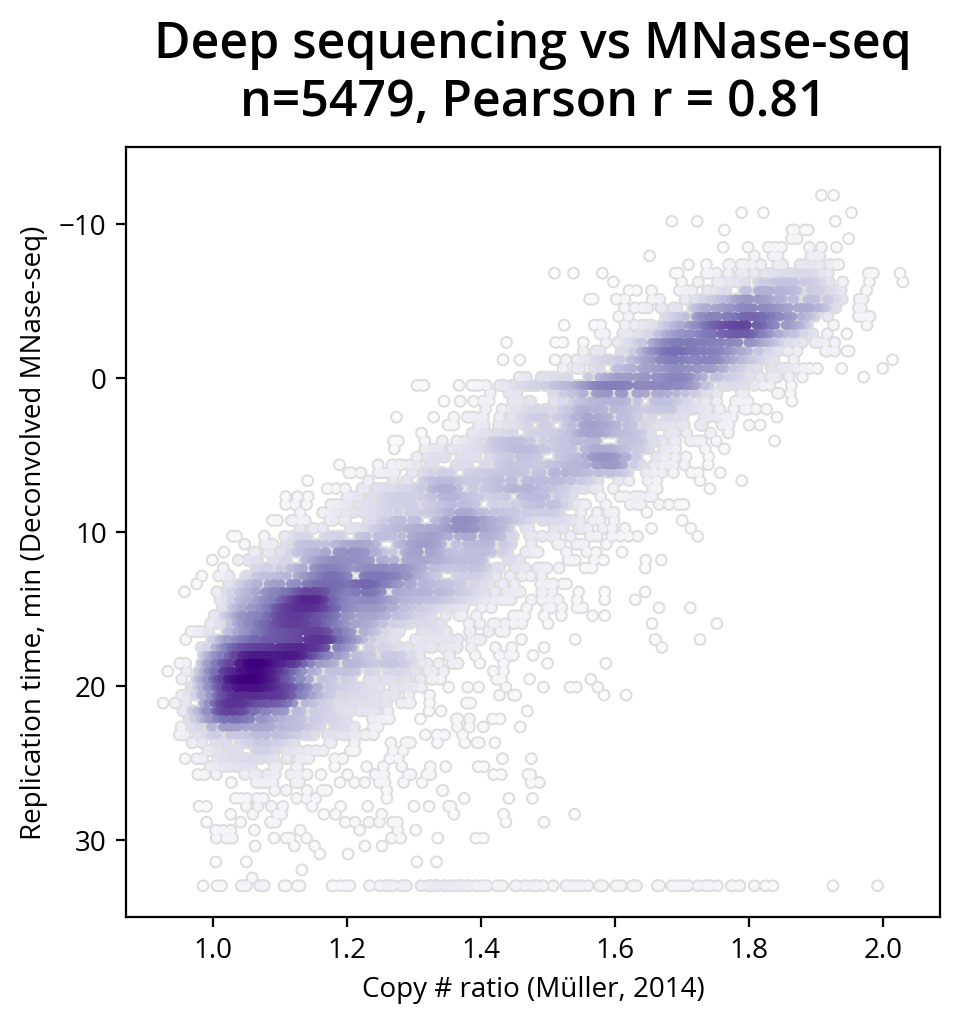

In [4]:
replication_timings.plot_chrom_timing(chrom=4)
replication_timings.plot_muller_correlation()


In [28]:
from pipeline.copy_correction_analysis import CopyCorrectionAnalysis

output_dir = 'output/draft3_run/'
copy_correction_analysis = CopyCorrectionAnalysis(output_dir)
copy_correction_analysis.load_means_all_chromosomes()


Chromosome 1...Skipped 0 entries
00:00:04.568
Chromosome 2...Skipped 0 entries
00:00:16.358
Chromosome 3...Skipped 0 entries
00:00:19.129
Chromosome 4...Skipped 0 entries
00:01:16.158
Chromosome 5...Skipped 0 entries
00:01:21.844
Chromosome 6...Skipped 0 entries
00:01:24.190
Chromosome 7...Skipped 0 entries
00:01:42.851
Chromosome 8...Skipped 0 entries
00:01:47.787
Chromosome 9...Skipped 0 entries
00:01:51.021
Chromosome 10...Skipped 0 entries
00:01:59.322
Chromosome 11...Skipped 0 entries
00:02:06.233
Chromosome 12...Skipped 0 entries
00:02:20.074
Chromosome 13...Skipped 0 entries
00:02:30.180
Chromosome 14...Skipped 0 entries
00:02:38.639
Chromosome 15...Skipped 1 entries
00:02:53.287
Chromosome 16...Skipped 0 entries
00:03:03.833


In [29]:
copy_correction_analysis.compute_ptrs()
copy_correction_analysis.select_example_windows()

In [32]:
copy_correction_analysis.initialize_replication_time_colormaps()

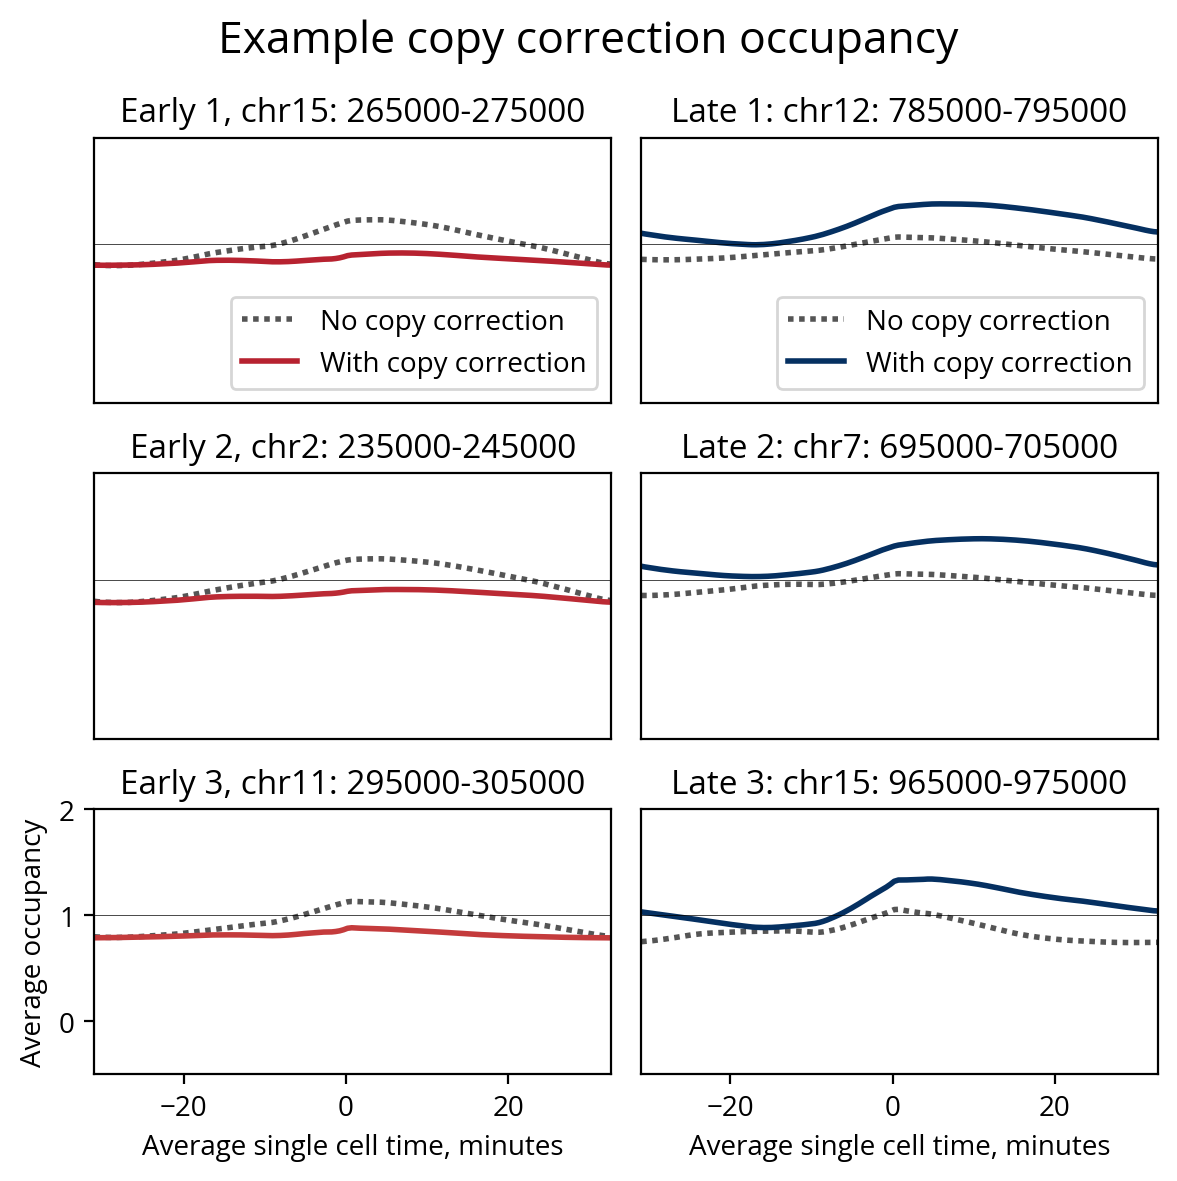

In [35]:
copy_correction_analysis.plot_sample_curves()

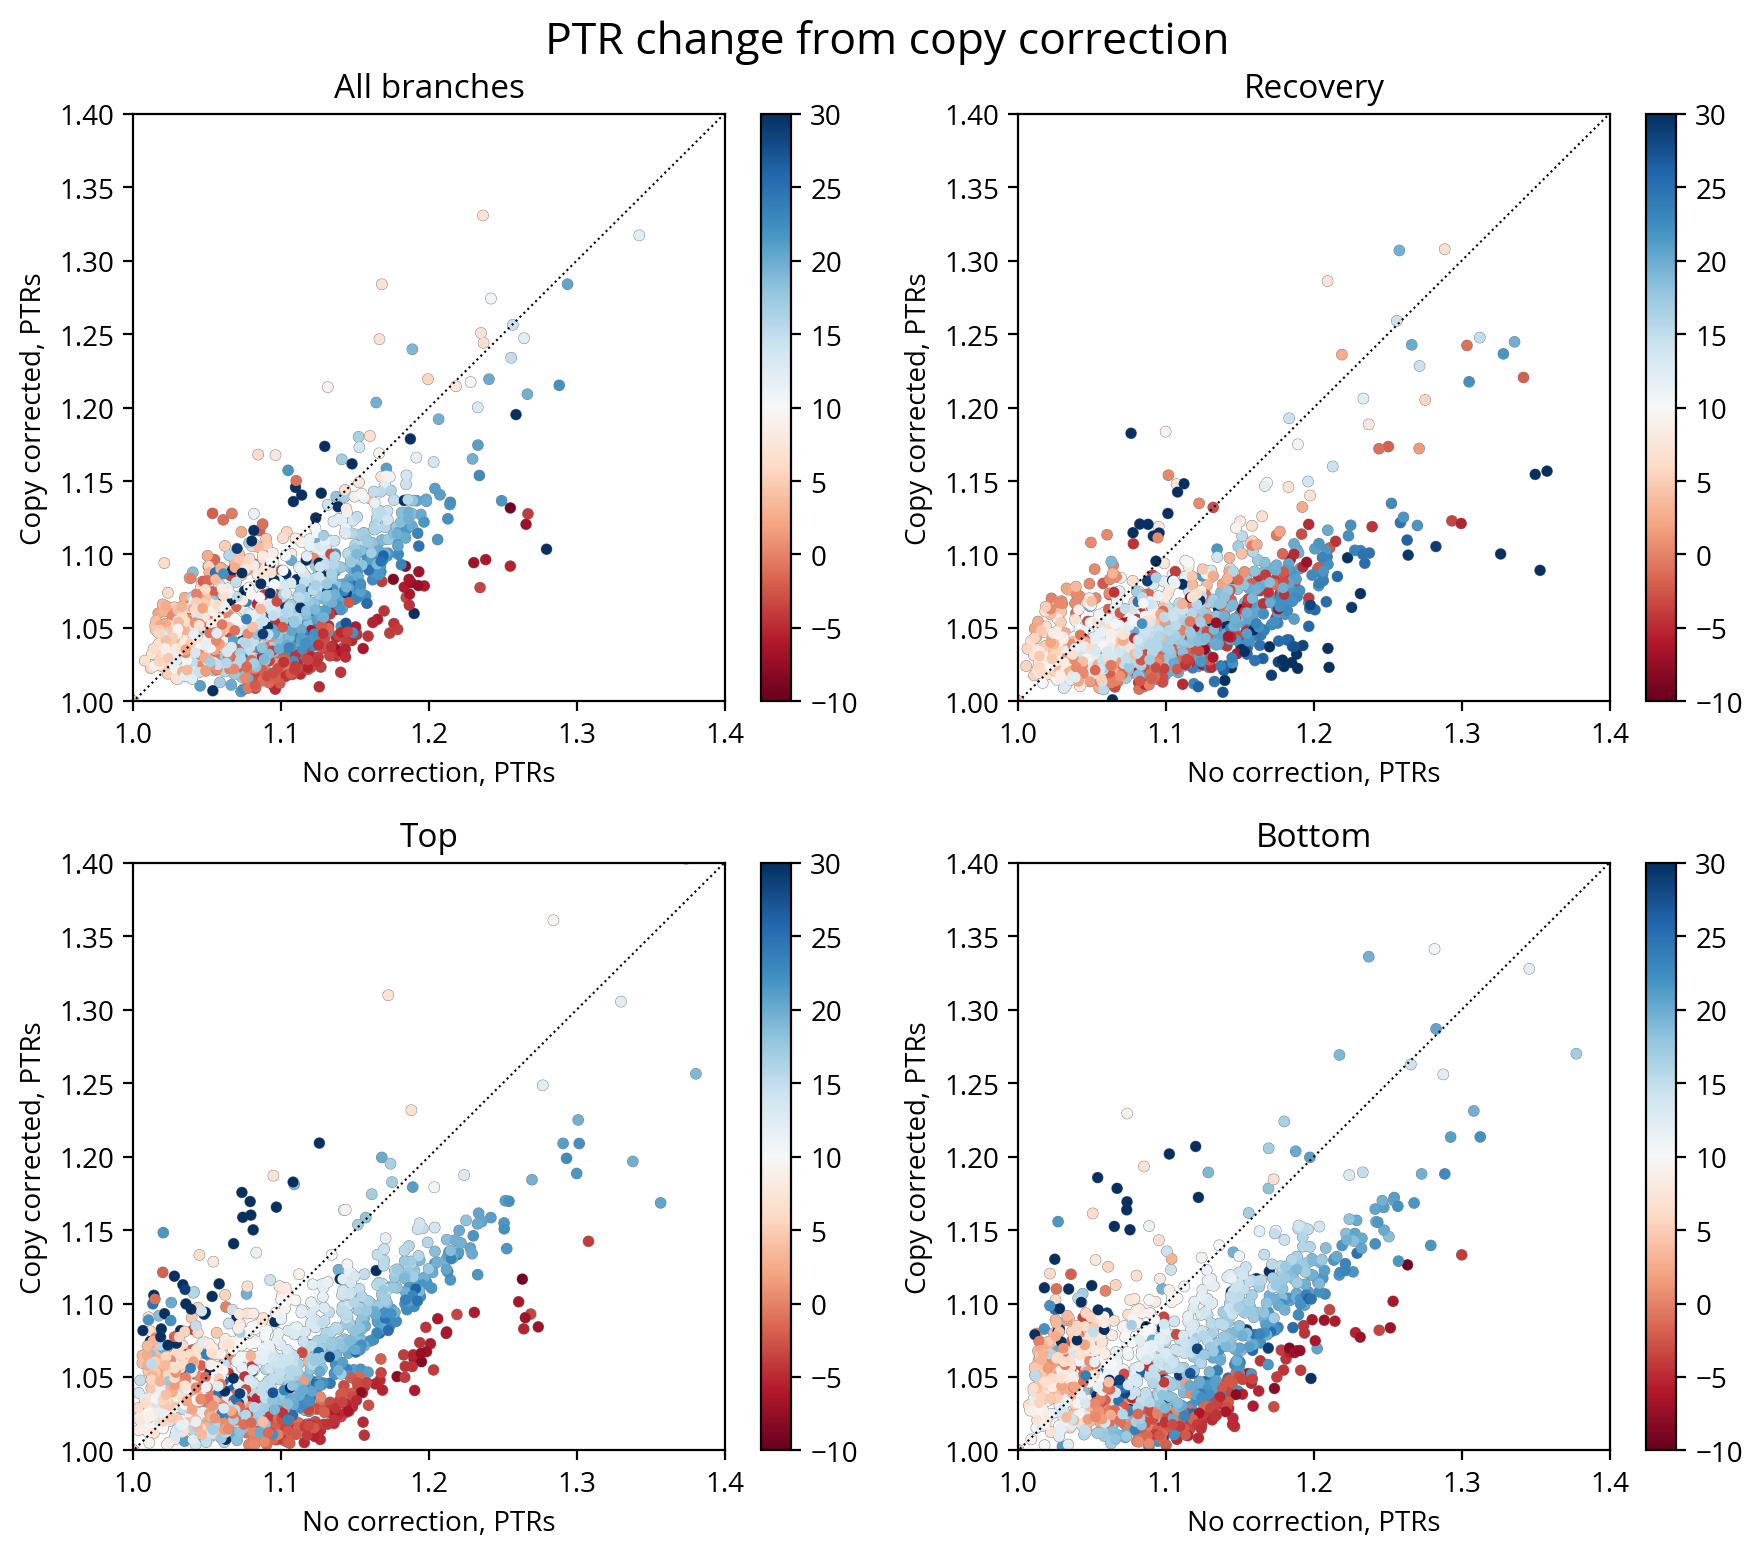

In [34]:
copy_correction_analysis.plot_branch_ptrs()

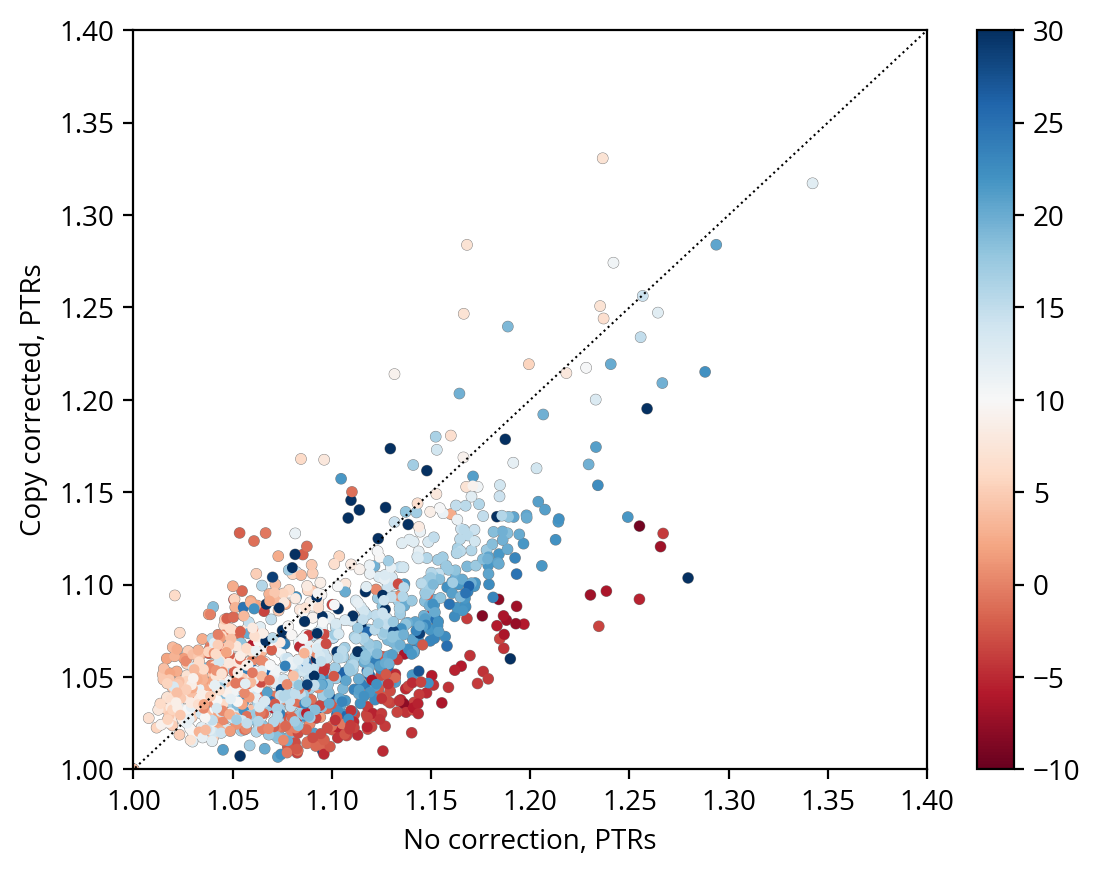

In [33]:
copy_correction_analysis.plot_ptrs()

In [81]:
from src.config import load_default_chrom_configs

def plot_comparison(F_loci_3_cc, F_loci_3_no_cc, b):
    config1, config2 = load_default_chrom_configs()
    i_tps = config1.get_timepoints_for_branch('i')
    t_tps = config1.get_timepoints_for_branch('t')
    b_tps = config1.get_timepoints_for_branch('b')
    tb_tps = (t_tps + b_tps)/2
    
    plt.figure(figsize=(7, 2))
    plt.subplot(1, 2, 1)
    plt.plot(i_tps, F_loci_3_cc.mean(1)[config1.i_indices()]*b, label="Copy corrected")
    plt.plot(i_tps, F_loci_3_no_cc.mean(1)[config1.i_indices()], label="No copy correction")
    plt.ylim(0.5, 1.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    f_cc_tb = (F_loci_3_cc.mean(1)[config1.t_indices()]*b +
               F_loci_3_cc.mean(1)[config1.b_indices()]*b)/2.
    f_no_cc_tb = (F_loci_3_no_cc.mean(1)[config1.t_indices()] +
                  F_loci_3_no_cc.mean(1)[config1.b_indices()])/2.

    plt.plot(t_tps, f_cc_tb)
    plt.plot(t_tps,f_no_cc_tb)
    plt.ylim(0.5, 1.5)


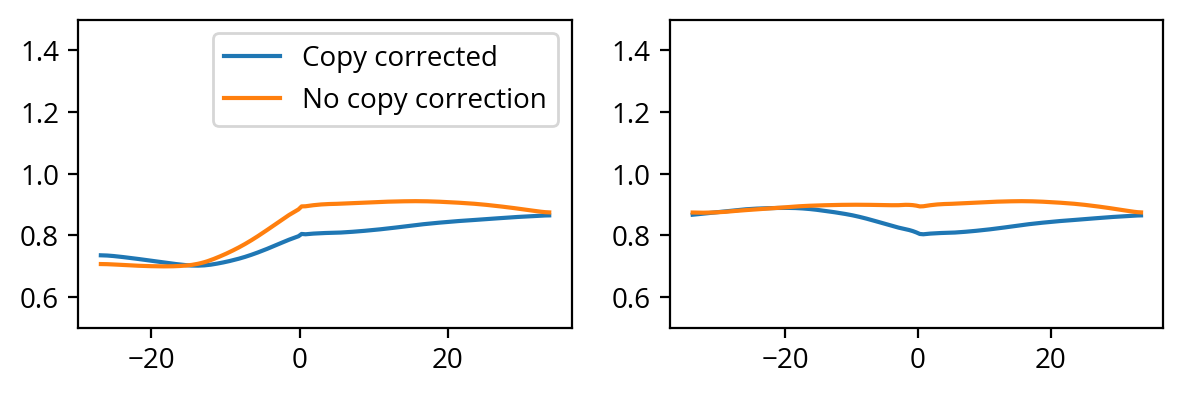

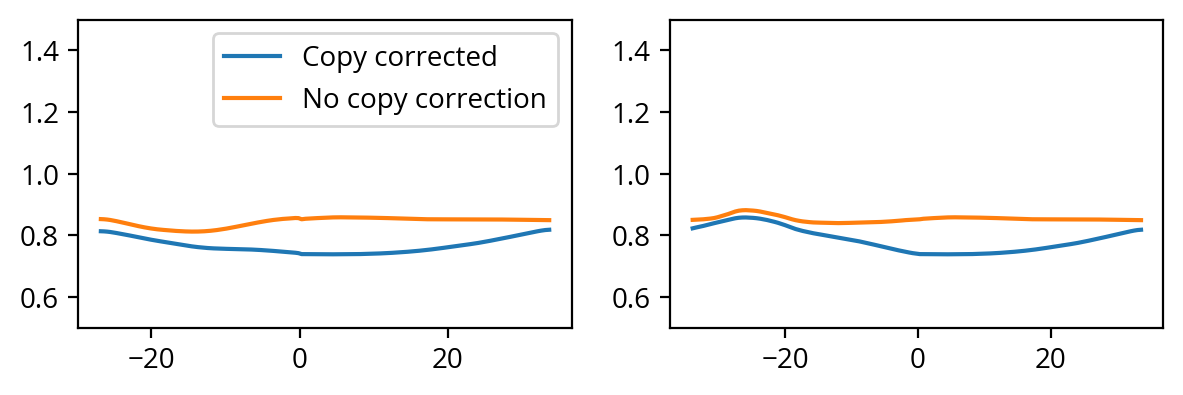

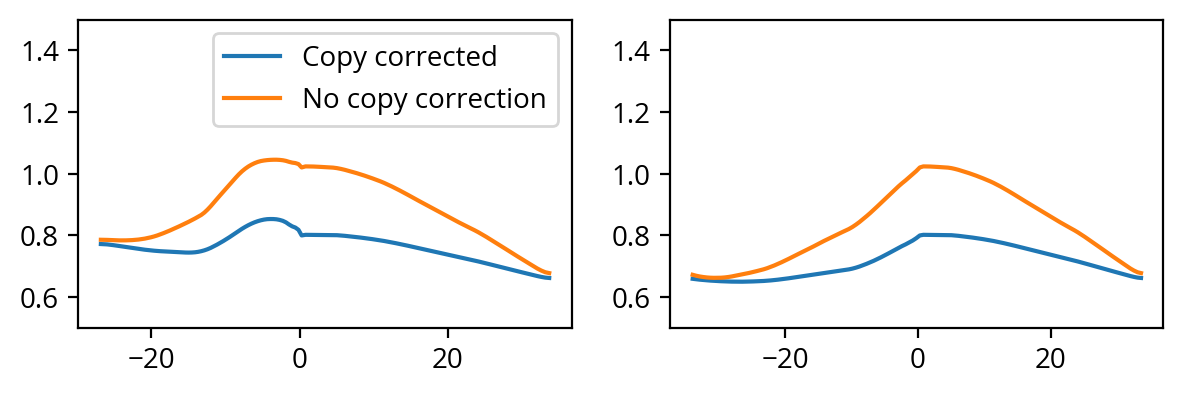

In [82]:
def load_cc_no_cc(output_dir, chrom, span):
    from src.RealDataReplication import read_n_fr_b

    center, N, fr, b = read_n_fr_b(chrom, span, 1, output_dir)
    F_loci_2_cc = np.load(
        f'{output_dir}/chromatin_deconvolution/deconvolution_data/chr{chrom}/chr{chrom}_{span[0]}_{span[1]}_F.npy')
    F_loci_2_no_cc = np.load(
            f'{output_dir}/chromatin_deconvolution_no_copy/deconvolution_data/chr{chrom}/chr{chrom}_{span[0]}_{span[1]}_F.npy')

    return F_loci_2_cc, F_loci_2_no_cc, b

F_loci_1_cc, F_loci_1_no_cc, b_1 = load_cc_no_cc('output/draft4_run/', 15, (260000, 270001))
F_loci_2_cc, F_loci_2_no_cc, b_2 = load_cc_no_cc('output/draft4_run/', 12, (780000, 790001))
F_loci_3_cc, F_loci_3_no_cc, b_3 = load_cc_no_cc('output/draft4_run/', 16, (770000, 780001))

plot_comparison(F_loci_1_cc, F_loci_1_no_cc, b_1)
plot_comparison(F_loci_2_cc, F_loci_2_no_cc, b_2)
plot_comparison(F_loci_3_cc, F_loci_3_no_cc, b_3)
